In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
sales = pd.read_csv("../../../Data/sales.csv")
products = pd.read_csv("../../../Data/products.csv")
stores = pd.read_csv("../../../Data/stores.csv")
category = pd.read_csv("../../../Data/category.csv")
warranty = pd.read_csv("../../../Data/warranty.csv")

Join sales.csv and products.csv to derive revenue (quantity × price), then plot the Top 10 products by revenue as a sorted bar chart

In [4]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)

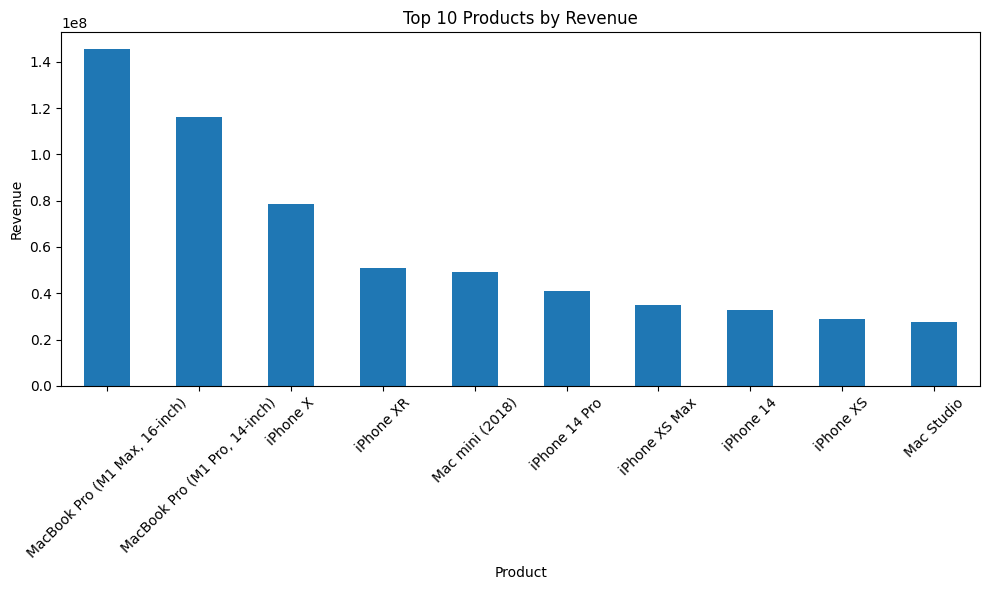

In [5]:
top_products = (
    sales_products
    .groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Join sales.csv, products.csv, and category.csv to plot revenue by category_name across all 10 categories, with value labels above
each bar.

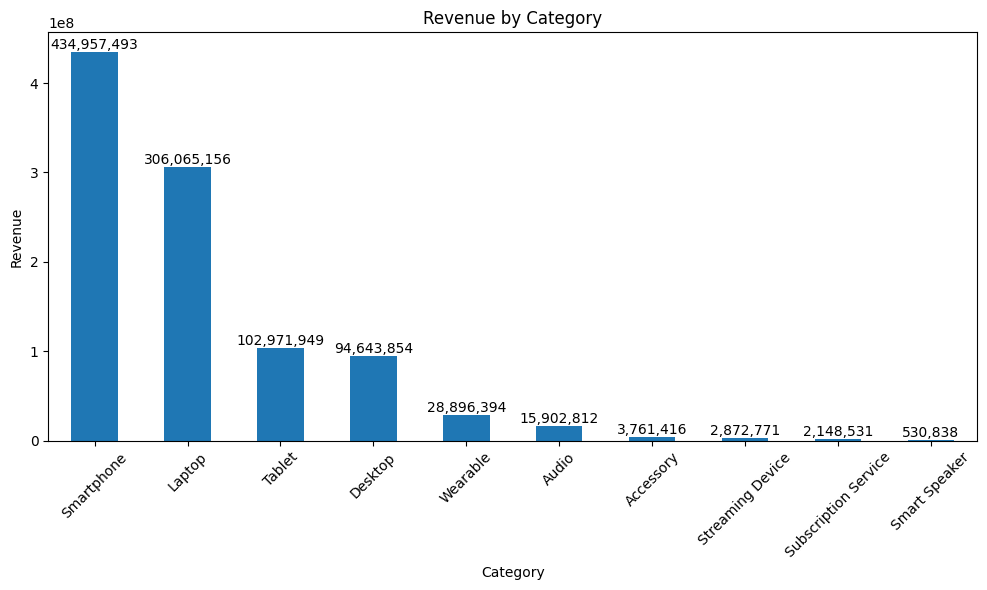

In [6]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)

sales_category = sales_products.merge(
    category,
    on="category_id",
    how="left"
)

category_revenue = (
    sales_category
    .groupby("category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

chart = category_revenue.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

for i, value in enumerate(category_revenue):
    chart.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Join sales.csv and stores.csv to plot the Top 15 stores by units sold as a horizontal bar chart, and explain why the Top 15 cutoff
matters.

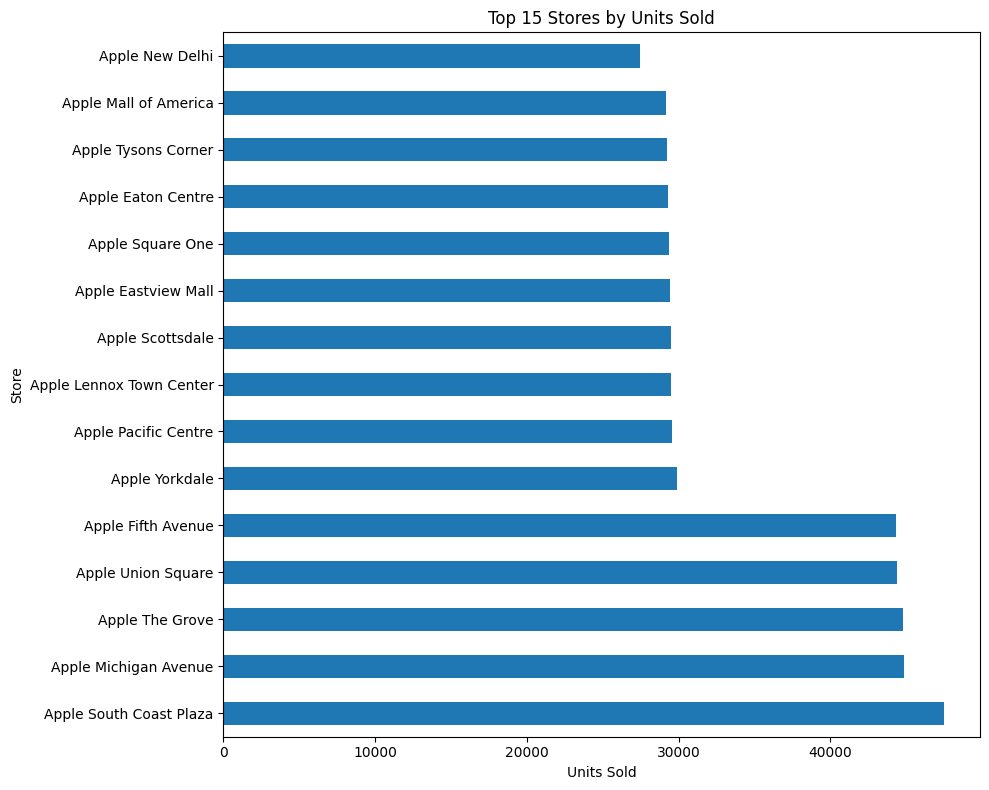

In [7]:
sales_stores = sales.merge(
    stores,
    on="store_id",
    how="left"
)

top_stores = (
    sales_stores
    .groupby("store_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_stores.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 15 Stores by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Store")

plt.tight_layout()
plt.show()

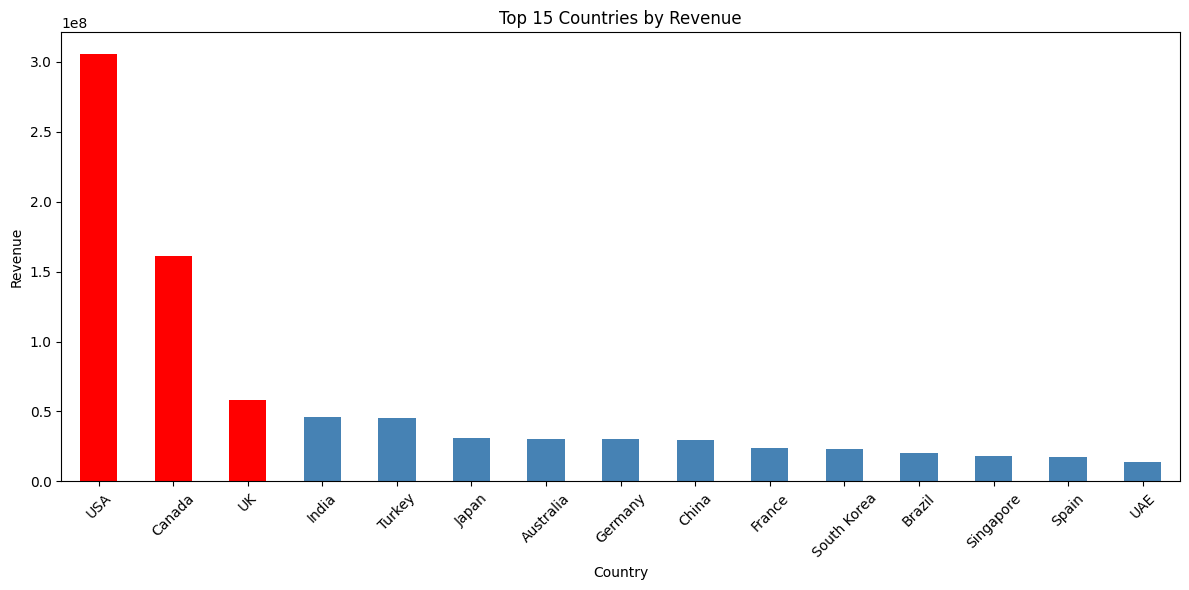

In [9]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)

sales_stores = sales_products.merge(
    stores,
    on="store_id",
    how="left"
)

country_revenue = (
    sales_stores
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

colors = ["red"] * 3 + ["steelblue"] * 12

country_revenue.plot(
    kind="bar",
    figsize=(12, 6),
    color=colors
)

plt.title("Top 15 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()